# Supplementary Figures S2–S7

Reproduces the quantitative panels of Supplementary Figures **S2–S7** from `./Data/Supplementary`.
Supplementary Figures S1, S8 and S9 do not have standalone numerical source-data tables.

Plotting: S2–S5 are strip plots (one dot per cell-type dataset, bar = mean); S6 shows the meQTL magnitude/direction panels; S7A–C show Melody-G ablation matrices.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
CSV_DIR = next((os.path.join(r, 'Data', 'Supplementary') for r in (os.getcwd(), os.path.dirname(os.getcwd())) if os.path.isdir(os.path.join(r, 'Data', 'Supplementary'))), './Data/Supplementary')
rng = np.random.default_rng(0)

def strip_grid(csv, group_col, groups, splits, metrics, colors, title, figw=14):
    df = pd.read_csv(f'{CSV_DIR}/{csv}')
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(figw, 3.6))
    if n == 1: axes = [axes]
    for ax, metric in zip(axes, metrics):
        sub = df[df['metric'] == metric]
        for gi, g in enumerate(groups):
            off = (gi - (len(groups) - 1) / 2) * (0.8 / len(groups))
            for si, sp in enumerate(splits):
                v = sub[(sub[group_col] == g) & (sub['split'] == sp)]['value'].to_numpy()
                if len(v) == 0: continue
                x = si + off + rng.uniform(-0.03, 0.03, len(v))
                ax.scatter(x, v, s=6, color=colors[gi], alpha=0.5, label=g if si == 0 else None)
                ax.plot([si+off-0.05, si+off+0.05], [v.mean()]*2, color=colors[gi], lw=1.4)
        ax.set_xticks(range(len(splits))); ax.set_xticklabels(splits, rotation=30, fontsize=7)
        ax.set_ylabel(metric); ax.set_title(metric, fontsize=9)
    axes[0].legend(fontsize=6, markerscale=2)
    fig.suptitle(title, y=1.03)
    plt.tight_layout(); plt.show()

## Supplementary Figure S2 — Comprehensive benchmark (all splits × all metrics)

Melody-MT/ST vs INTERACT/CpGenie/iDNA-ABT across five splits and five metrics.


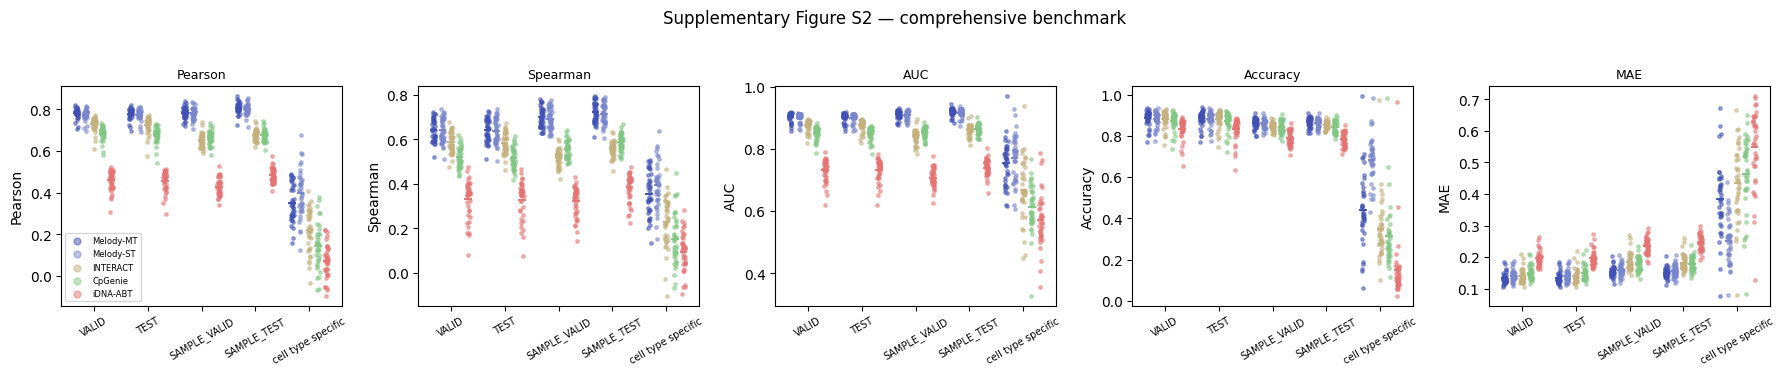

In [2]:
strip_grid('figure_S2.csv', 'model',
    ['Melody-MT','Melody-ST','INTERACT','CpGenie','iDNA-ABT'],
    ['VALID','TEST','SAMPLE_VALID','SAMPLE_TEST','cell type specific'],
    ['Pearson','Spearman','AUC','Accuracy','MAE'],
    ['#3F51B5','#7986CB','#C4B17D','#81C784','#E57373'],
    'Supplementary Figure S2 — comprehensive benchmark', figw=18)

## Supplementary Figure S3 — Contribution of input sequence length
Melody-MT at 1/2/10/20/50 kb and Melody-ST vs baselines across four genome-wide splits
(Pearson/Spearman/AUC).

/var/folders/f8/4qmbqwxd66qffc_z38kwwzgc0000gn/T/ipykernel_19967/3622145550.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis', len(glen))


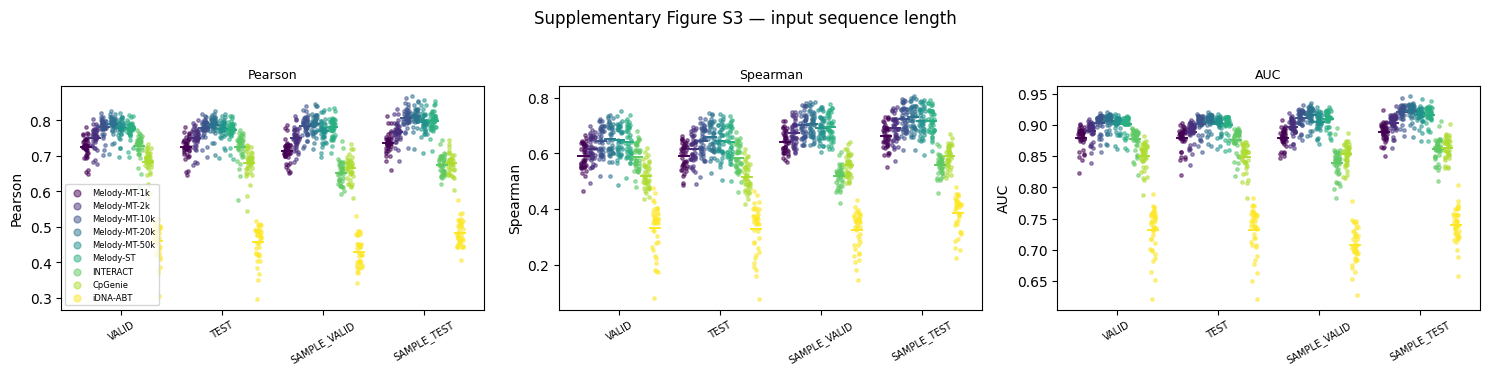

In [3]:
import matplotlib as mpl
glen = ['Melody-MT-1k','Melody-MT-2k','Melody-MT-10k','Melody-MT-20k','Melody-MT-50k','Melody-ST','INTERACT','CpGenie','iDNA-ABT']
cmap = mpl.cm.get_cmap('viridis', len(glen))
colors = [cmap(i) for i in range(len(glen))]
strip_grid('figure_S3.csv', 'model', glen,
    ['VALID','TEST','SAMPLE_VALID','SAMPLE_TEST'],
    ['Pearson','Spearman','AUC'], colors,
    'Supplementary Figure S3 — input sequence length', figw=15)

## Supplementary Figure S4 — (alpha, beta) loss-weight sensitivity
Five (alpha, beta) configurations across splits and metrics. Robust genome-wide; lowest cell-type-specific MAE at (8,32).

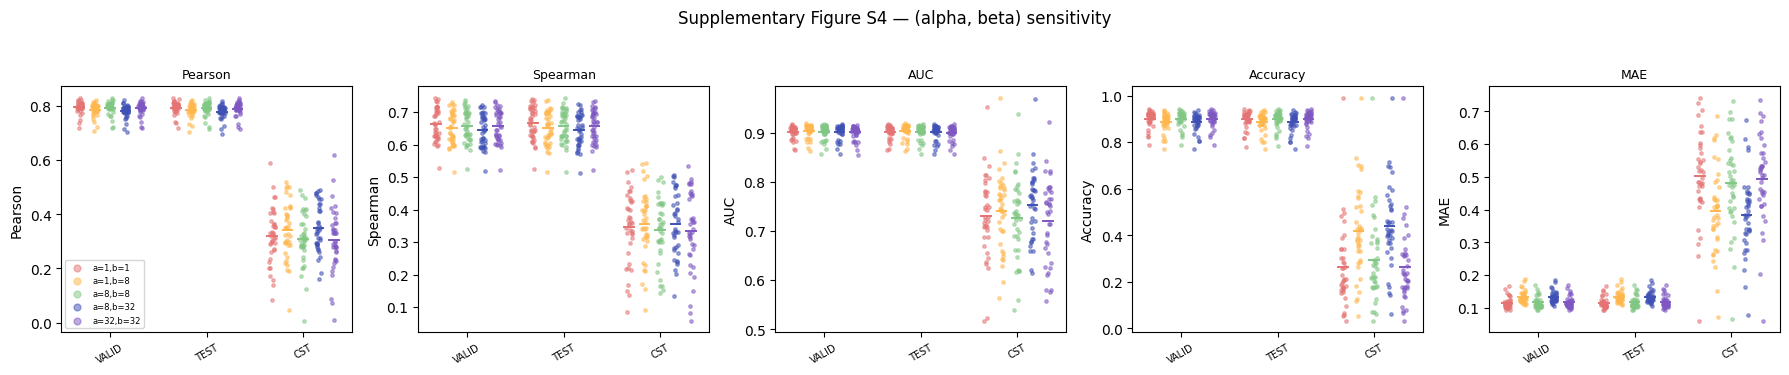

In [4]:
cfgs = ['a=1,b=1','a=1,b=8','a=8,b=8','a=8,b=32','a=32,b=32']
colors = ['#E57373','#FFB74D','#81C784','#3F51B5','#7E57C2']
strip_grid('figure_S4.csv', 'alpha_beta', cfgs,
    ['VALID','TEST','CST'],
    ['Pearson','Spearman','AUC','Accuracy','MAE'], colors,
    'Supplementary Figure S4 — (alpha, beta) sensitivity', figw=18)

## Supplementary Figure S5 — CpG-count auxiliary loss (on vs off)
Melody-MT trained with vs without the CpG-count auxiliary loss, on validation/test chromosomes.

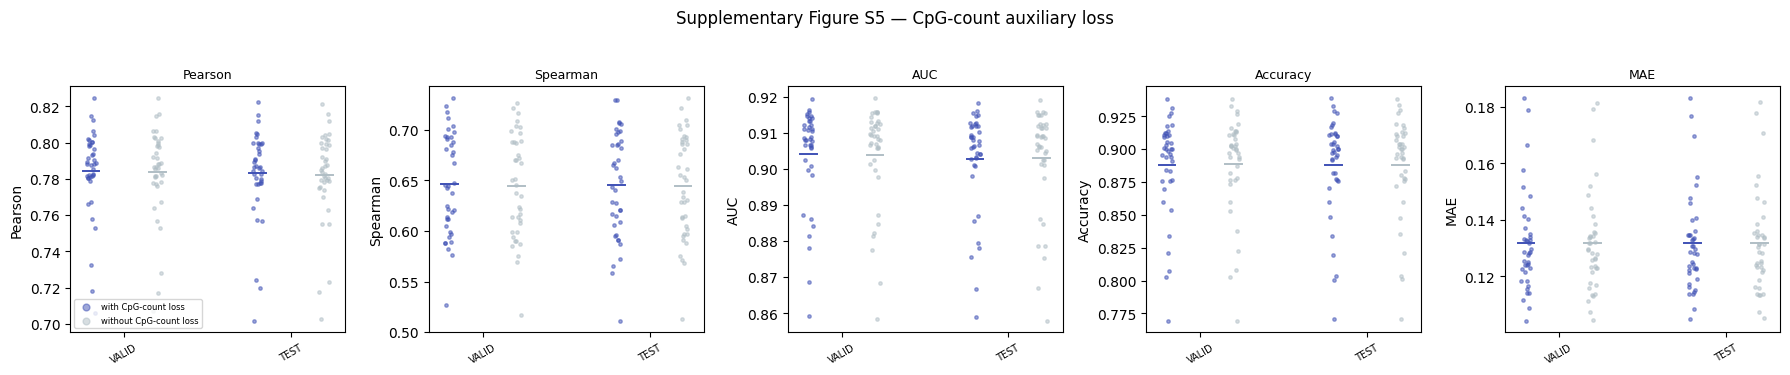

In [5]:
strip_grid('figure_S5.csv', 'config',
    ['with CpG-count loss','without CpG-count loss'],
    ['VALID','TEST'],
    ['Pearson','Spearman','AUC','Accuracy','MAE'],
    ['#3F51B5','#B0BEC5'],
    'Supplementary Figure S5 — CpG-count auxiliary loss', figw=18)

## Supplementary Figure S6 — meQTL effect: magnitude and direction

(A) Pearson correlation between absolute observed and predicted effect sizes; (B) directional consistency, per dataset and model, at the 0–1000 bp distance window.


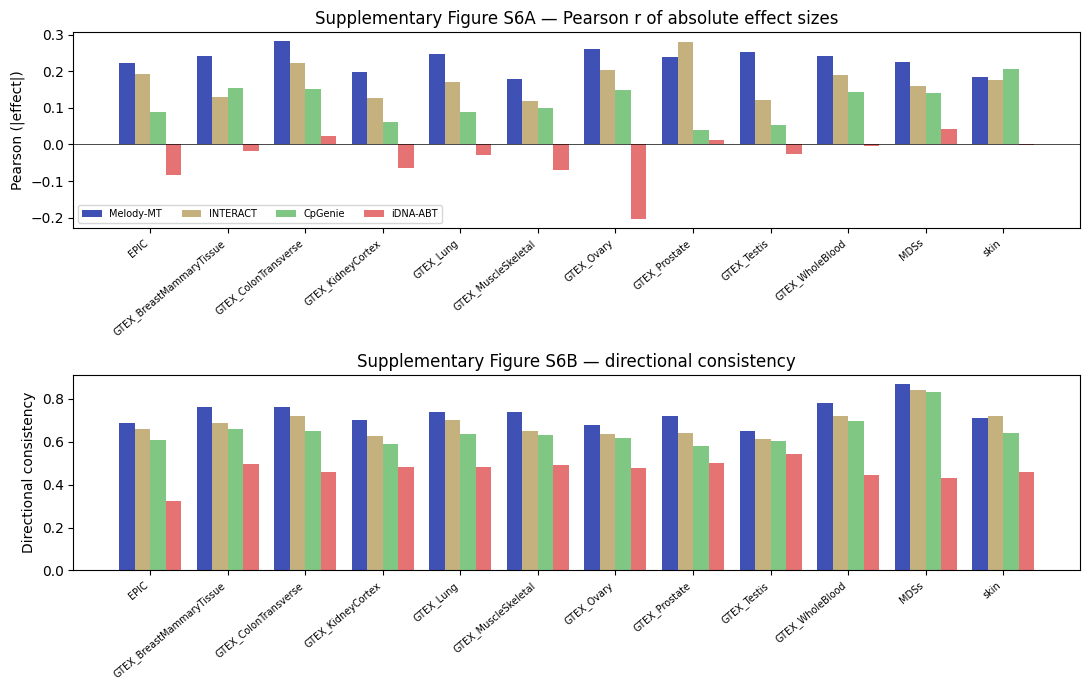

In [6]:
df = pd.read_csv(f'{CSV_DIR}/figure_S6.csv')
models = ['Melody-MT','INTERACT','CpGenie','iDNA-ABT']
colors = {'Melody-MT':'#3F51B5','INTERACT':'#C4B17D','CpGenie':'#81C784','iDNA-ABT':'#E57373'}
datasets = sorted(df['meQTL_dataset'].unique())
x = np.arange(len(datasets)); w = 0.2
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for ax, col, lbl in zip(axes, ['pearson_r_of_absolute_effect_sizes','directional_consistency'],
                        ['Pearson (|effect|)','Directional consistency']):
    for mi, m in enumerate(models):
        vals = [df[(df['meQTL_dataset']==d)&(df['model']==m)][col].mean() for d in datasets]
        ax.bar(x + (mi-1.5)*w, vals, w, color=colors[m], label=m)
    ax.set_xticks(x); ax.set_xticklabels(datasets, rotation=40, ha='right', fontsize=7)
    ax.set_ylabel(lbl); ax.axhline(0, color='k', lw=0.5)
axes[0].set_title('Supplementary Figure S6A — Pearson r of absolute effect sizes'); axes[0].legend(fontsize=7, ncol=4)
axes[1].set_title('Supplementary Figure S6B — directional consistency')
plt.tight_layout(); plt.show()

## Supplementary Figure S7A–C — Melody-G ablation matrices

AUC across five unseen cell types for the transcriptomic-sampling, input-length and model-configuration ablations reported in panels S7A–C.


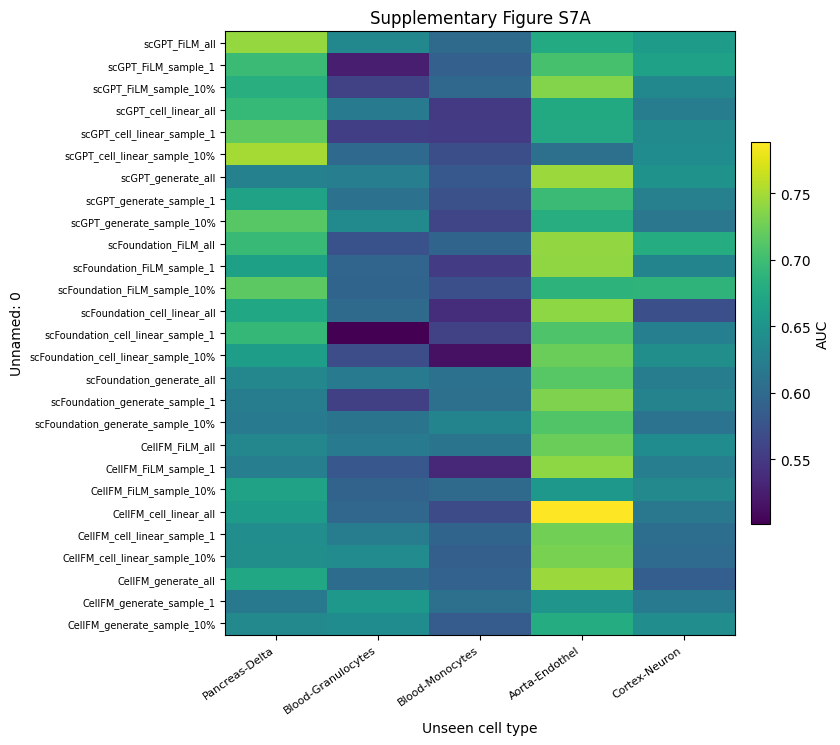

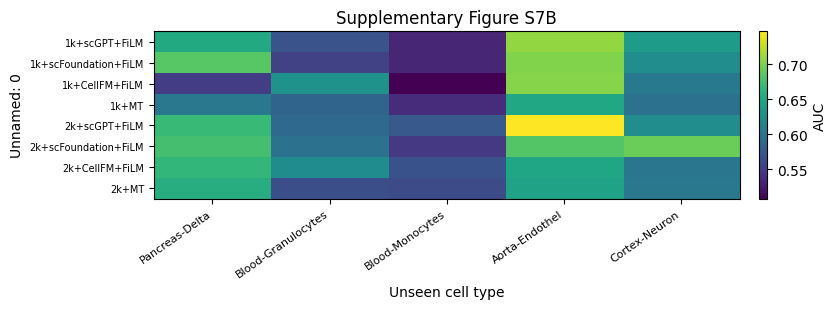

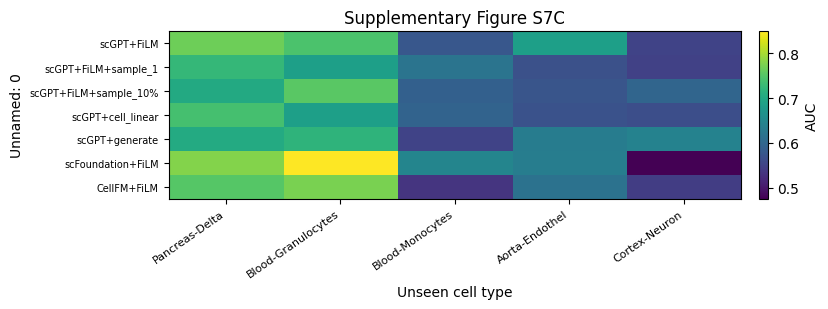

In [7]:
def plot_auc_matrix(csv, title):
    df = pd.read_csv(f'{CSV_DIR}/{csv}')
    row_label = df.columns[0]
    matrix = df.set_index(row_label).astype(float)
    fig_h = max(3.2, 0.28 * len(matrix))
    fig, ax = plt.subplots(figsize=(8.5, fig_h))
    image = ax.imshow(matrix.to_numpy(), aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=35, ha='right', fontsize=8)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=7)
    ax.set_xlabel('Unseen cell type'); ax.set_ylabel(row_label); ax.set_title(title)
    fig.colorbar(image, ax=ax, label='AUC', fraction=0.035, pad=0.03)
    plt.tight_layout(); plt.show()

plot_auc_matrix('figure_S7A.csv', 'Supplementary Figure S7A')
plot_auc_matrix('figure_S7B.csv', 'Supplementary Figure S7B')
plot_auc_matrix('figure_S7C.csv', 'Supplementary Figure S7C')
